In [2]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Multicampus-8/4_머신러닝_딥러닝/프로젝트(시험점수예측)/'

train_df = pd.read_csv(DATA_PATH + "data/train.csv")
test_df = pd.read_csv(DATA_PATH + "data/test.csv")
sample_submission_df = pd.read_csv(DATA_PATH + "data/sample_submission.csv")
target = "exam_score"


Mounted at /content/drive


In [4]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error


RANDOM_STATE = 42

# ===============================
# 1️⃣ ID 컬럼 자동 감지
# ===============================
id_col = "id" if "id" in test_df.columns else test_df.columns[0]
print("ID column:", id_col)

# ===============================
# 2️⃣ X / y 분리
# ===============================
X = train_df.drop(columns=[target])
y = train_df[target].astype(float)

# ===============================
# 3️⃣ 수치형 / 범주형 분리
# ===============================
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("Numeric:", len(numeric_features), "Categorical:", len(categorical_features))

# ===============================
# 4️⃣ 전처리 + 모델 파이프라인
# ===============================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=800,
    random_state=RANDOM_STATE
)

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", model)
])

# ===============================
# 5️⃣ 5-Fold CV (RMSE)
# ===============================
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
neg_mse = cross_val_score(pipe, X, y, cv=cv, scoring="neg_mean_squared_error")
rmse_scores = np.sqrt(-neg_mse)

print(f"[CV] RMSE mean = {rmse_scores.mean():.5f}")
print(f"[CV] RMSE std  = {rmse_scores.std():.5f}")

# ===============================
# 6️⃣ 전체 학습 후 예측
# ===============================
pipe.fit(X, y)
pred = pipe.predict(test_df)

# 점수 범위 클리핑 (선택)
pred = np.clip(pred, 0, 100)

# ===============================
# 7️⃣ submission 파일 생성
# ===============================
submission = pd.DataFrame({
    id_col: test_df[id_col],
    target: pred
})

save_path = DATA_PATH + "submission.csv"
submission.to_csv(save_path, index=False)

print("Saved to:", save_path)

ID column: id
Numeric: 5 Categorical: 7
[CV] RMSE mean = 8.78395
[CV] RMSE std  = 0.01189
Saved to: /content/drive/MyDrive/Colab Notebooks/Multicampus-8/4_머신러닝_딥러닝/프로젝트(시험점수예측)/submission.csv


In [5]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# ===============================
# Permutation Importance 계산
# ===============================
result = permutation_importance(
    pipe,
    X,
    y,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_squared_error"
)

# 컬럼 이름 가져오기
feature_names = X.columns

# 중요도 정리
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": result.importances_mean
})

# 중요도 정규화 (합 = 1 로 만들기)
importance_df["Importance"] = importance_df["Importance"] / importance_df["Importance"].sum()

# 정렬
importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
4,study_hours,0.719042
5,class_attendance,0.121714
8,sleep_quality,0.053488
9,study_method,0.044744
10,facility_rating,0.034942
7,sleep_hours,0.022675
0,id,0.001081
1,age,0.000819
3,course,0.000788
2,gender,0.000380


In [6]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# 속도용 샘플링
N = min(3000, len(X))
X_s = X.sample(N, random_state=42)
y_s = y.loc[X_s.index]

result = permutation_importance(
    pipe,
    X_s,
    y_s,
    n_repeats=3,
    random_state=42,
    scoring="neg_root_mean_squared_error",  # RMSE로 바로 (sklearn 지원)
    n_jobs=-1                    # 병렬 (가능하면 빨라짐)
)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

# 크기 비교가 목적이라 clip 처리
importance_df["Importance"] = importance_df["Importance"].clip(lower=0)

# 정규화(합=1)
s = importance_df["Importance"].sum()
importance_df["Importance"] = importance_df["Importance"] / s if s > 0 else importance_df["Importance"]

importance_df.head(10)

,Feature,Importance
4,study_hours,0.621270
5,class_attendance,0.158324
8,sleep_quality,0.074546
9,study_method,0.060374
10,facility_rating,0.047044
7,sleep_hours,0.033315
1,age,0.001436
3,course,0.001352
0,id,0.001248
2,gender,0.000602


In [ ]:
top4 = importance_df.head(6)
top4

,Feature,Importance
4,study_hours,0.621270
5,class_attendance,0.158324
8,sleep_quality,0.074546
9,study_method,0.060374
10,facility_rating,0.047044
7,sleep_hours,0.033315


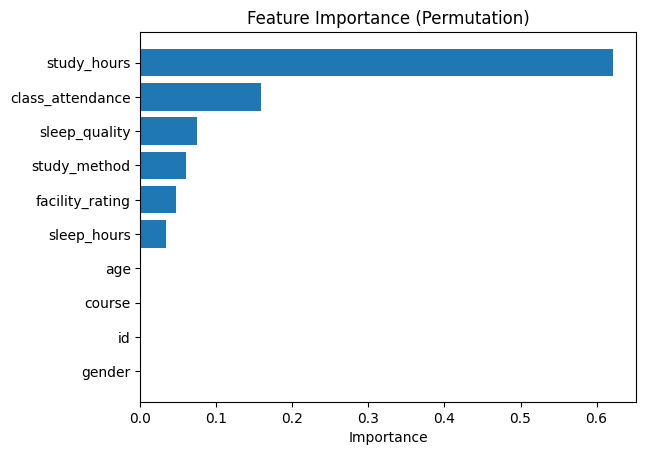

In [ ]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance (Permutation)")
plt.show()